<a href="https://colab.research.google.com/github/Sneha-code01/ML/blob/main/ml_8functiontransformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import FunctionTransformer

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
df = pd.read_csv("/content/titanic.csv")[['Age','Survived','Fare']]
df['Age'].fillna(df['Age'].mean(),inplace=True)


/tmp/ipykernel_1667/3146959127.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


,Age,Survived,Fare
849,29.699118,1,89.1042
325,36.000000,1,135.6333
861,21.000000,0,11.5000
569,32.000000,1,7.8542
96,71.000000,0,34.6542


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(df.drop('Survived',axis=1),df.iloc[:,1],random_state=42)
x_train

,Age,Fare
298,29.699118,30.5000
884,25.000000,7.0500
247,24.000000,14.5000
478,22.000000,7.5208
305,0.920000,151.5500
...,...,...
106,21.000000,7.6500
270,29.699118,31.0000
860,41.000000,14.1083
435,14.000000,120.0000


/tmp/ipykernel_1667/562964299.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Fare'])


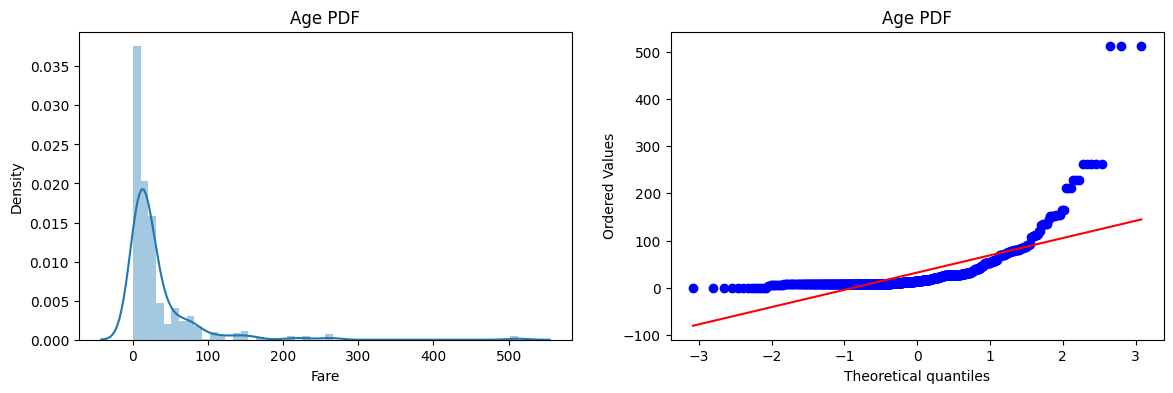

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train['Fare'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(x_train['Fare'],dist='norm',plot=plt)
plt.title('Age PDF')
plt.show()

In [ ]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)

predy1 = clf.predict(x_test)
predy2 = clf2.predict(x_test)

print("accuracy LR",accuracy_score(y_test,predy1))
print("accuracy DT",accuracy_score(y_test,predy2))

accuracy LR 0.6636771300448431
accuracy DT 0.6905829596412556


In [ ]:
trf = FunctionTransformer(func=np.log1p)

x_train_transformed = trf.fit_transform(x_train)
x_test_transformed = trf.fit_transform(x_test)

clf.fit(x_train_transformed,y_train)
clf.fit(x_test_transformed,y_test)

predy1 = clf.predict(x_test_transformed)
predy2 = clf2.predict(x_test_transformed)

print("accuracy LR",accuracy_score(y_test,predy1))
print("accuracy DT",accuracy_score(y_test,predy2))

accuracy LR 0.7085201793721974
accuracy DT 0.3991031390134529


/tmp/ipykernel_1667/1949786242.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train_transformed['Fare'])


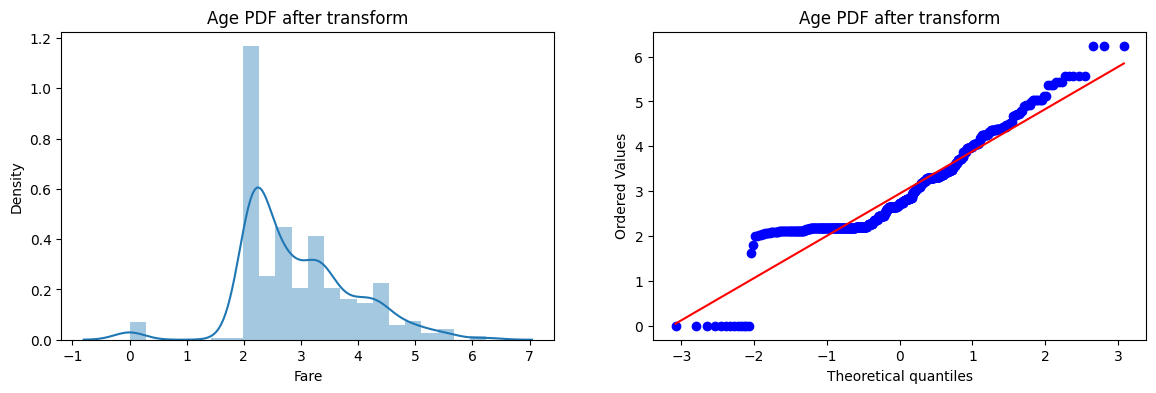

/tmp/ipykernel_1667/1949786242.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train_transformed['Age'])


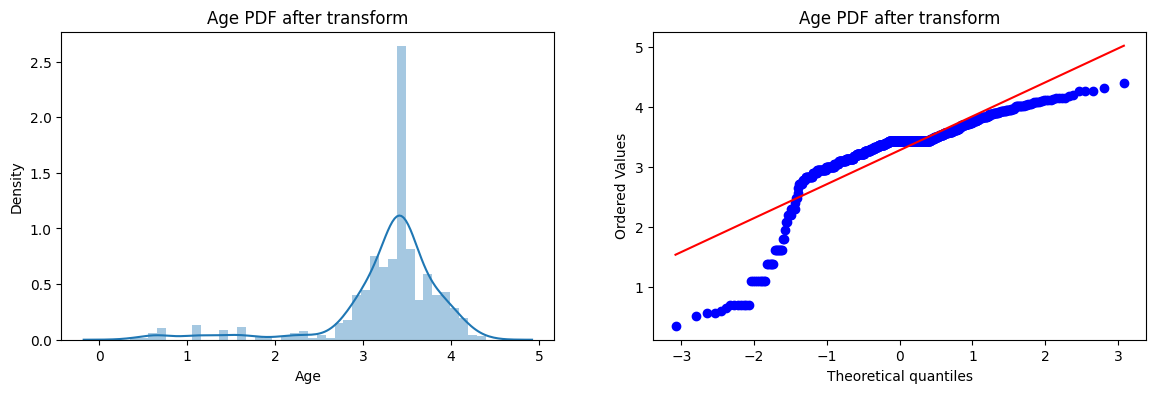

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train_transformed['Fare'])
plt.title('Age PDF after transform')

plt.subplot(122)
stats.probplot(x_train_transformed['Fare'],dist='norm',plot=plt)
plt.title('Age PDF after transform')
plt.show()

plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train_transformed['Age'])
plt.title('Age PDF after transform')

plt.subplot(122)
stats.probplot(x_train_transformed['Age'],dist='norm',plot=plt)
plt.title('Age PDF after transform')
plt.show()